# Tensile and Rolling &mdash; seven branches, two microstructures

| | Branch | Loading | Starts from |
|---|---|---|---|
| **A** | Tensile in X | uniaxial tension, +10 % | initial RVE |
| **B** | Tensile in Y | uniaxial tension, +10 % | initial RVE |
| **C** | Tensile in Z | uniaxial tension, +10 % | initial RVE |
| **D** | Cold Rolling in X | plane-strain compression, &minus;30 % | initial RVE |
| **E** | Tensile in X | uniaxial tension, +10 % | **D's rolled microstructure** |
| **F** | Tensile in Y | uniaxial tension, +10 % | **D's rolled microstructure** |
| **G** | Tensile in Z | uniaxial tension, +10 % | **D's rolled microstructure** |

A, B and C measure how the as-generated microstructure responds along each
axis. D is the processing step. E, F and G repeat the same three tensile
tests on the microstructure that rolling produced &mdash; so comparing A vs E,
B vs F and C vs G shows what cold rolling did to the mechanical anisotropy.

**The EBSD map, the statistics and the RVE are computed once.** A&ndash;D all
hang off that single RVE, and E&ndash;G all hang off D's rolled result, so
every difference comes from the loading and nothing else.

### How E, F and G get their microstructure

DAMASK cannot restart from a deformed grid: after 30 % compression the voxels
are neither cubic nor uniform. So branch D runs with `do_regridding=True`,
which **recovers** a regular grid carrying the evolved grains and
orientations, and stamps it with a `microstructure_state_id`.

`initiate_from_dataObject` then promotes that recovered snapshot to
`microstructure[0]` of a brand-new data object and lifts its evolved
orientations into the phase block &mdash; because DAMASK reads geometry from
`microstructure[0]` and texture from `phase[].orientation.euler_angles`, and
would otherwise silently re-simulate the *undeformed* structure.

The id travels through the workflow graph (`wf.branch_D.outputs.recovered_state_id`),
so the whole thing runs in one `wf.run()`.

<img src="images/Figure%205.1.png"
     alt="Workflow: EBSD to RVE, four branches, then post-rolling branches"
     style="max-width:100%; height:auto;">

## Setup

In [1]:
import logging
logging.disable(logging.WARNING)

import sys
import orix
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[1]))

from pyiron_workflow import Workflow

# Function nodes: the individual pipeline steps.
from functions.nodes import (
    load_ebsd_map, get_stats, generate_rve,
)

from functions.macros import simulate_case, simulate_branch

## 1. RVE settings

Same size as Version15/Version16 used (15 voxels, 15 um). Smaller than the
Cold Rolling case's 20&sup3; grid, because this notebook runs the solver four
times.

In [2]:
nvox  = 15                  # Number of voxels in each Cartesian direction (Nx = Ny = Nz = nvox -> cubic RVE)
lside = 15                  # Side length of the RVE in um in each direction
periodic_RVE = True         # Generate a periodic RVE in Kanapy

# Grain-size cutoffs: they truncate the measured grain-size distribution so
#
# Background: the EBSD map's real grain population has a median equivalent
# diameter of ~41 um. A representative RVE at that grain size would need a
# box of 250-300 um per side, far too expensive. So this RVE deliberately
# samples only the FINE fraction of the real microstructure -- it is not a
# scaled-down version of the whole material. Keep that in mind when reusing it.
deq_min_RVE = 3.0
deq_max_RVE = 11.0

ebsd_file = "ebsd_316L_500x500.ang"

#n_threads = 10              # OpenMP threads for DAMASK_grid (single MPI process)

## 2. The load cases

Each load case is written as **two complementary tensors**:

- `magnitude[0]` &mdash; prescribed strain (the deformation gradient)
- `magnitude[1]` &mdash; prescribed stress

Every component must be prescribed in exactly **one** of the two; the other
carries the placeholder `"x"`, meaning "solver determines this". Prescribing
both, or neither, does not crash DAMASK &mdash; it silently simulates
different physics, so it is worth reading these carefully.

Conventions used below:

- **Tensile (A, B, C and E, F, G)**: strain prescribed along the pulled axis;
  the other two axes are stress-free (`0.0` in the stress tensor) so the
  sample contracts freely.
- **Rolling (D)**: X compressed; Z held at zero strain (the rolls confine the
  width); Y stress-free so material flows and thickens.

E, F and G reuse A, B and C's load cases exactly: same axes, same +10 %
strain.

In [3]:
# Common to all four load cases
VERTEX_LIST = ["V000", "V001", "V101", "V100", "V010", "V011", "V111", "V110"]
DURATION = 100.0    # total load-case time  -> 100 increments at step 1.0
STEP     = 1.0      # reduce DURATION for a quick trial run


# ---- A: uniaxial tension along X, +10 % -------------------------------
boundary_condition_A = {
    "mechanical_BC": [
        {
            "vertex_list": VERTEX_LIST,
            "loading_type": "strain-stress",
            "loading_mode": "monotonic",
            "applied_load": [
                {
                    "magnitude": [
                        # strain: pull X; Y and Z solved
                        {"xx": 0.1, "yy": "x", "zz": "x",
                         "xy": 0.0, "xz": 0.0, "yz": 0.0},
                        # stress: Y and Z stress-free (free contraction)
                        {"xx": "x", "yy": 0.0, "zz": 0.0,
                         "xy": "x", "xz": "x", "yz": "x"},
                    ],
                    "duration": DURATION,
                    "step": STEP,
                }
            ],
        }
    ]
}

# ---- B: uniaxial tension along Y, +10 % -------------------------------
boundary_condition_B = {
    "mechanical_BC": [
        {
            "vertex_list": VERTEX_LIST,
            "loading_type": "strain-stress",
            "loading_mode": "monotonic",
            "applied_load": [
                {
                    "magnitude": [
                        {"xx": "x", "yy": 0.1, "zz": "x",
                         "xy": 0.0, "xz": 0.0, "yz": 0.0},
                        {"xx": 0.0, "yy": "x", "zz": 0.0,
                         "xy": "x", "xz": "x", "yz": "x"},
                    ],
                    "duration": DURATION,
                    "step": STEP,
                }
            ],
        }
    ]
}

# ---- C: uniaxial tension along Z, +10 % -------------------------------
boundary_condition_C = {
    "mechanical_BC": [
        {
            "vertex_list": VERTEX_LIST,
            "loading_type": "strain-stress",
            "loading_mode": "monotonic",
            "applied_load": [
                {
                    "magnitude": [
                        {"xx": "x", "yy": "x", "zz": 0.1,
                         "xy": 0.0, "xz": 0.0, "yz": 0.0},
                        {"xx": 0.0, "yy": 0.0, "zz": "x",
                         "xy": "x", "xz": "x", "yz": "x"},
                    ],
                    "duration": DURATION,
                    "step": STEP,
                }
            ],
        }
    ]
}

# ---- D: cold rolling along X, -30 % plane-strain compression ----------
boundary_condition_D = {
    "mechanical_BC": [
        {
            "vertex_list": VERTEX_LIST,
            "loading_type": "strain-stress",
            "loading_mode": "monotonic",
            "applied_load": [
                {
                    "magnitude": [
                        # strain: X compressed 30 %; Z confined at zero strain
                        {"xx": -0.3, "yy": "x", "zz": 0.0,
                         "xy": 0.0, "xz": 0.0, "yz": 0.0},
                        # stress: Y stress-free -> free to thicken
                        {"xx": "x", "yy": 0.0, "zz": "x",
                         "xy": "x", "xz": "x", "yz": "x"},
                    ],
                    "duration": DURATION,
                    "step": STEP,
                }
            ],
        }
    ]
}


# E, F and G are the same three tensile tests as A, B and C -- only the
# starting microstructure differs, so the load cases are reused as-is.
boundary_condition_E = boundary_condition_A   # tension along X, post-rolling
boundary_condition_F = boundary_condition_B   # tension along Y, post-rolling
boundary_condition_G = boundary_condition_C   # tension along Z, post-rolling

## 3. Metadata, phase and units

Shared by all four branches. Only the title and description differ per
branch, so those are set as small overrides rather than four full copies.

In [4]:
base_metadata = {
    "$schema": "https://github.com/Ronakshoghi/MetadataSchema/blob/main/microstructure_sensitive_mechanical_metadata_schema.json",
    "title": "",          # set per branch below
    "creator": ["Rezek, Yousef"],
    "creator_ORCID": ["0009-0009-7588-6401"],
    "creator_affiliation": ["Ruhr University Bochum"],
    "creator_institute": ["Interdisciplinary Centre for Advanced Materials Simulation"],
    "creator_group": ["Micromechanical and Macroscopic Modelling"],
    "contributor": ["Hartmaier, Alexander"],
    "contributor_ORCID": ["0000-0002-3710-1169"],
    "contributor_affiliation": ["Ruhr University Bochum"],
    "contributor_institute": ["Interdisciplinary Centre for Advanced Materials Simulation"],
    "contributor_group": ["Micromechanical and Macroscopic Modelling"],
    "date": "",           # filled in by write_data
    "shared_with": [{"access_type": "c"}, {"access_type": "all"}],
    "description": "",    # set per branch below
    "rights": "Creative Commons Attribution 4.0 International",
    "rights_holder": ["Ruhr University Bochum"],
    "funder_name": "",
    "fund_identifier": "",
    "publisher": "",
    "relation": [],
    "keywords": ["crystal plasticity", "DAMASK", "Kanapy", "316L"],
}

_shared_note = (
    "This run shares its initial RVE with the other branches of this case, "
    "so differences between them come only from the load case. The RVE's "
    "grain-size distribution is truncated (deq_min=5.0 um, deq_max=13.0 um) "
    "and represents the fine-grain fraction of the measured EBSD "
    "microstructure, not its overall grain size."
)

user_metadata_A = {
    **base_metadata,
    "title": "Crystal plasticity simulation of 316L: uniaxial tension along X",
    "description": "Uniaxial tension along X to +10 % engineering strain, "
                   "FFT spectral solver, DAMASK. " + _shared_note,
}

user_metadata_B = {
    **base_metadata,
    "title": "Crystal plasticity simulation of 316L: uniaxial tension along Y",
    "description": "Uniaxial tension along Y to +10 % engineering strain, "
                   "FFT spectral solver, DAMASK. " + _shared_note,
}

user_metadata_C = {
    **base_metadata,
    "title": "Crystal plasticity simulation of 316L: uniaxial tension along Z",
    "description": "Uniaxial tension along Z to +10 % engineering strain, "
                   "FFT spectral solver, DAMASK. " + _shared_note,
}

user_metadata_D = {
    **base_metadata,
    "title": "Crystal plasticity simulation of 316L: cold rolling along X",
    "description": "Cold rolling (plane-strain compression) along X to -30 % "
                   "engineering strain. X is the rolling/compression direction, "
                   "Z is the transverse direction held at zero strain, Y is "
                   "stress-free so the material thickens. " + _shared_note,
}


_post_rolling_note = (
    "This run starts from the microstructure produced by the cold-rolling "
    "branch of this case (initialized_from), recovered onto a regular grid, "
    "carrying its evolved grains and crystallographic texture."
)

user_metadata_E = {
    **base_metadata,
    "title": "Crystal plasticity simulation of 316L: post-rolling uniaxial tension along X",
    "description": "Uniaxial tension along X to +10 % engineering strain, "
                   "FFT spectral solver, DAMASK. " + _post_rolling_note,
}

user_metadata_F = {
    **base_metadata,
    "title": "Crystal plasticity simulation of 316L: post-rolling uniaxial tension along Y",
    "description": "Uniaxial tension along Y to +10 % engineering strain, "
                   "FFT spectral solver, DAMASK. " + _post_rolling_note,
}

user_metadata_G = {
    **base_metadata,
    "title": "Crystal plasticity simulation of 316L: post-rolling uniaxial tension along Z",
    "description": "Uniaxial tension along Z to +10 % engineering strain, "
                   "FFT spectral solver, DAMASK. " + _post_rolling_note,
}


units = {
    "Stress": "Pa",
    "Strain": 1,
    "Length": "m",
    "Angle": "rad",
    "Temperature": "K",
    "Force": "N",
    "Stiffness": "Pa",
    "Time": "s",
}

In [5]:
# Phase and constitutive model. Shared by all four branches.
#
# NOTE: write_data fills in orientation.euler_angles, grain_count and
# orientation_identifier from the generated RVE. It assigns those arrays
# (it does not append), so using this same object for all four branches
# is safe.
phase = [
    {
        "phase_id": 0,
        "phase_name": "Iron",
        "volume_fraction": 1.0,
        "lattice_structure": "fcc",
        "constitutive_model": {
            "$schema": "https://raw.githubusercontent.com/Ronakshoghi/MetadataSchema/main/crystal_plasticity_constitutive_model_metadata_schema.json",
            "elastic_model_name": "hooke",
            "elastic_parameters": {
                "C11": 106.75e+9,
                "C12": 60.41e+9,
                "C44": 28.34e+9,
            },
            "plastic_model_name": "phenopowerlaw",
            "plastic_parameters": {
                "N_sl": [12],
                "a_sl": [2.25],
                "atol_xi": 1.0,
                "dot_gamma_0_sl": [0.001],
                "h_0_sl-sl": [75.e+6],
                "h_sl-sl": [1, 1, 1.4, 1.4, 1.4, 1.4, 1.4],
                "n_sl": [20],
                "output": ["xi_sl"],
                "xi_0_sl": [31.e+6],
                "xi_inf_sl": [63.e+6],
            },
        },
        "orientation": {
            "euler_angles": {"Phi1": [], "Phi": [], "Phi2": []},
            "grain_count": None,
            "orientation_identifier": None,
            "crystal_symmetry_group": "m-3m",
            "software": "orix",
            "software_version": orix.__version__,
        },
    }
]

## 4. Solver and post-processing settings

The two roles need different post-processing, so the settings are split.

**Tensile branches (A, B, C, E, F, G)** &mdash; only the mechanical response
matters. `export_microstructure=False` means no deformed snapshots are
appended; `microstructure[0]`, written by `write_data`/`initiate_from_dataObject`
before the solver runs, is kept as-is. Segmentation, grain tracking and IPF
colours are off, since they only apply to exported snapshots. This keeps the
files small &mdash; snapshots were most of the Cold Rolling case's 1.1 GB.

**Rolling branch (D)** &mdash; needs the full treatment, because E, F and G
have to start from its microstructure: snapshots exported, segmentation and
grain tracking on, and crucially `do_regridding=True` to recover a regular
grid and stamp it with an id.

In [6]:
# DAMASK input-file controls (load_to_damask) -- same for every branch
f_out_list     = (1,)      # write results every increment
f_restart_list = (100,)    # write a restart file every 100 increments
damask_outputs = ("F", "P", "F_p", "F_e", "L_p", "O")   # fields requested per phase

quantities = ("O", "F", "sigma", "epsilon_V^0.0(F)")


# ---- Tensile branches: mechanical response + the initial microstructure only
tensile_pp = dict(
    quantities=quantities,
    export_microstructure=False,     # no deformed snapshots appended;
                                     # microstructure[0] is kept untouched
    export_mechanical_response=True,
    export_vtk=False,
    do_segmentation=False,           # needs exported snapshots
    do_grain_tracking=False,         # needs exported snapshots
    add_ipf_colors=False,            # needs exported snapshots
    do_regridding=False,             # nothing branches off these runs
)

# ---- Rolling branch: full treatment, because E/F/G start from its result
rolling_pp = dict(
    quantities=quantities,
    export_microstructure=True,      # required by do_segmentation
    export_mechanical_response=True,
    microstructure_stride=10,        # ~10 snapshots over 100 increments
    export_vtk=True,
    do_segmentation=True,            # find the new grains rolling created
    do_grain_tracking=True,          # follow grains across increments
    add_ipf_colors=True,
    do_regridding=True,              # REQUIRED: recovers a regular grid and
                                     # stamps it with a microstructure_state_id,
                                     # which is what E/F/G branch from
)

## 5. Shared front end: EBSD &rarr; statistics &rarr; RVE

Runs **once**. All four branches connect to this single `generate_rve` node.

In [7]:
wf = Workflow("tensile_and_rolling")

# Step 1: Load and read the EBSD map
wf.load_ebsd_map = load_ebsd_map(
    file_path=ebsd_file,
    show_plot=True,
)

# Step 2: Extract microstructure statistics from the EBSD map.
# deq_min/deq_max truncate the fitted grain-size distribution to fit the
# target box. Other cutoffs stay at Kanapy's data-driven defaults.
wf.get_stats = get_stats(
    source=wf.load_ebsd_map,
    NVoxels=nvox,
    sizeRVE=lside,
    periodic=periodic_RVE,
    deq_min=deq_min_RVE,
    deq_max=deq_max_RVE,
)

# Step 3: Generate the RVE -- ONCE, shared by every branch.
#
# ori=wf.load_ebsd_map reuses the real EBSD-derived orientation distribution
# on the synthetic RVE geometry. Pass ori="random" for a random texture.
# report_grain_geometry=True prints achieved-vs-target grain statistics so
# the truncation above can be checked rather than trusted.
wf.generate_rve = generate_rve(
    source=wf.get_stats,
    ori=wf.load_ebsd_map,
    show_plots=True,
    report_grain_geometry=True,
)

## 6. The branches

One macro call per branch:

- `simulate_case` &nbsp;= `write_data → load_to_damask → run_damask → post_processing`
- `simulate_branch` = `initiate_from_dataObject → load_to_damask → run_damask → post_processing`

Both share the same tail, so E, F and G behave identically to A, B and C once
their starting microstructure is built.

To run only some branches, comment out the ones you do not want &mdash; but
note **E, F and G depend on D**.

In [8]:
# =====================================================================
# A, B, C, D  --  from the initial RVE
# =====================================================================

# --- A: tensile in X --------------------------------------------------
wf.branch_A = simulate_case(
    RVE=wf.generate_rve,
    user_metadata=user_metadata_A,
    boundary_condition=boundary_condition_A,
    phase=phase, units=units, base_work_dir="Keys",
    f_out_list=f_out_list, f_restart_list=f_restart_list,
    damask_outputs=damask_outputs, n_threads=n_threads,
    **tensile_pp,
)

# --- B: tensile in Y --------------------------------------------------
wf.branch_B = simulate_case(
    RVE=wf.generate_rve,
    user_metadata=user_metadata_B,
    boundary_condition=boundary_condition_B,
    phase=phase, units=units, base_work_dir="Keys",
    f_out_list=f_out_list, f_restart_list=f_restart_list,
    damask_outputs=damask_outputs, n_threads=n_threads,
    **tensile_pp,
)

# --- C: tensile in Z --------------------------------------------------
wf.branch_C = simulate_case(
    RVE=wf.generate_rve,
    user_metadata=user_metadata_C,
    boundary_condition=boundary_condition_C,
    phase=phase, units=units, base_work_dir="Keys",
    f_out_list=f_out_list, f_restart_list=f_restart_list,
    damask_outputs=damask_outputs, n_threads=n_threads,
    **tensile_pp,
)

# --- D: cold rolling in X ---------------------------------------------
# The only branch with the full post-processing treatment: E, F and G start
# from the microstructure this run produces.
wf.branch_D = simulate_case(
    RVE=wf.generate_rve,
    user_metadata=user_metadata_D,
    boundary_condition=boundary_condition_D,
    phase=phase, units=units, base_work_dir="Keys",
    f_out_list=f_out_list, f_restart_list=f_restart_list,
    damask_outputs=damask_outputs, n_threads=n_threads,
    **rolling_pp,
)


# =====================================================================
# E, F, G  --  from D's recovered (rolled) microstructure
#
# source                  = D's finished MiMeDO object
# microstructure_state_id = the id D stamped on its recovered snapshot
#
# Both are wired from D's outputs, so the id never has to be copied by
# hand and E/F/G run in the same wf.run() as D.
# =====================================================================

# --- E: tensile in X, post-rolling ------------------------------------
wf.branch_E = simulate_branch(
    source=wf.branch_D.outputs.UpdatedDataObject,
    microstructure_state_id=wf.branch_D.outputs.recovered_state_id,
    user_metadata=user_metadata_E,
    boundary_condition=boundary_condition_E,
    phase=phase, units=units, base_work_dir="Keys",
    f_out_list=f_out_list, f_restart_list=f_restart_list,
    damask_outputs=damask_outputs, n_threads=n_threads,
    **tensile_pp,
)

# --- F: tensile in Y, post-rolling ------------------------------------
wf.branch_F = simulate_branch(
    source=wf.branch_D.outputs.UpdatedDataObject,
    microstructure_state_id=wf.branch_D.outputs.recovered_state_id,
    user_metadata=user_metadata_F,
    boundary_condition=boundary_condition_F,
    phase=phase, units=units, base_work_dir="Keys",
    f_out_list=f_out_list, f_restart_list=f_restart_list,
    damask_outputs=damask_outputs, n_threads=n_threads,
    **tensile_pp,
)

# --- G: tensile in Z, post-rolling ------------------------------------
wf.branch_G = simulate_branch(
    source=wf.branch_D.outputs.UpdatedDataObject,
    microstructure_state_id=wf.branch_D.outputs.recovered_state_id,
    user_metadata=user_metadata_G,
    boundary_condition=boundary_condition_G,
    phase=phase, units=units, base_work_dir="Keys",
    f_out_list=f_out_list, f_restart_list=f_restart_list,
    damask_outputs=damask_outputs, n_threads=n_threads,
    **tensile_pp,
)

## 7. Inspect the graph before running

Worth a look before starting four solver runs: the four branches should all
originate from the single `generate_rve` node.

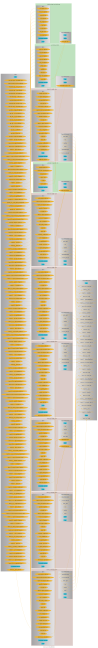

In [9]:
wf.draw(size=(14, 9))

## 8. Execute

This launches the real `DAMASK_grid` solver once per branch.

########################################################################################
 Loading EBSD map ....................................................................



Imported EBSD map with 1 phases.
Initial number of bad pixels: 3040
After 3041 loops: number of bad pixels: 0
Identifying regions of homogeneous misorientations and assigning them to grains.
Phase #0 (Iron fcc): Identified Grains: 199
Building microstructure graph.
After boundary-artifact pre-merge, 95 grains left.
Starting to simplify microstructure graph.
After merging of similar regions, 94 grains left.
After elimination of small grains, 94 grains left.

--------------------------------------------------------
Statistical microstructure parameters in pixel map 
--------------------------------------------------------
37.3829204177711 36.458300058977386
11.823723098220658 12.212733009155695
41.3258994072946 37.68895663473972


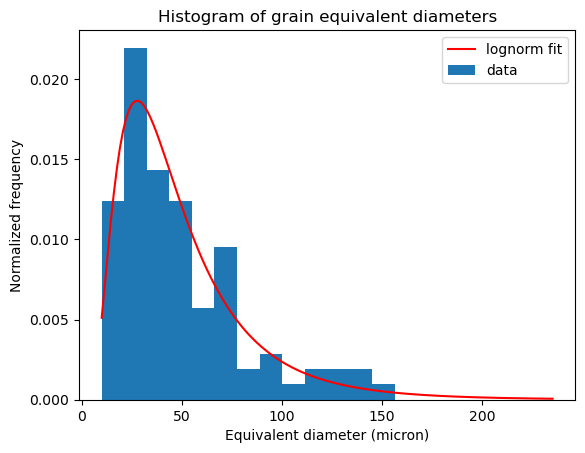

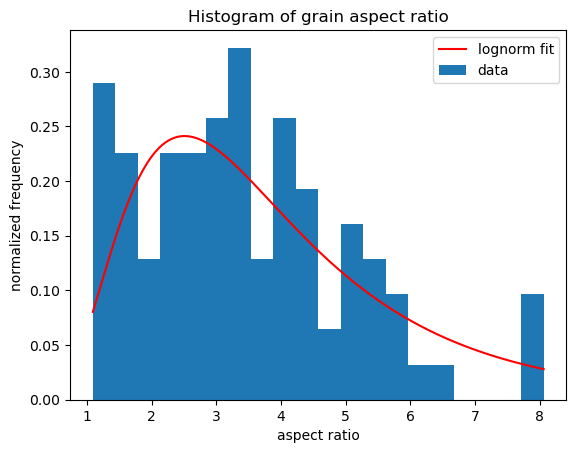

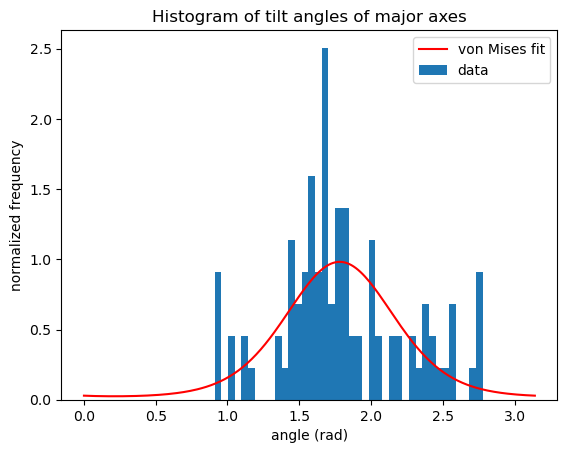

Analyzed microstructure of phase #0 (Iron fcc) with 94 grains.
Median values: equiv. diameter: 41.326 micron, aspect ratio: 3.441, tilt angle: 24.213°
Std. dev: equivalent diameter: 0.632 micron, aspect ratio: 0.563, tilt angle: 52.828°


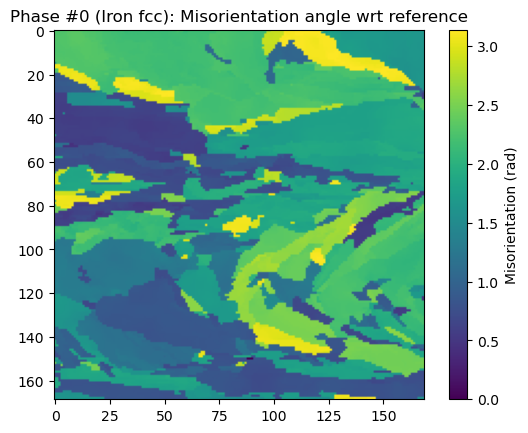

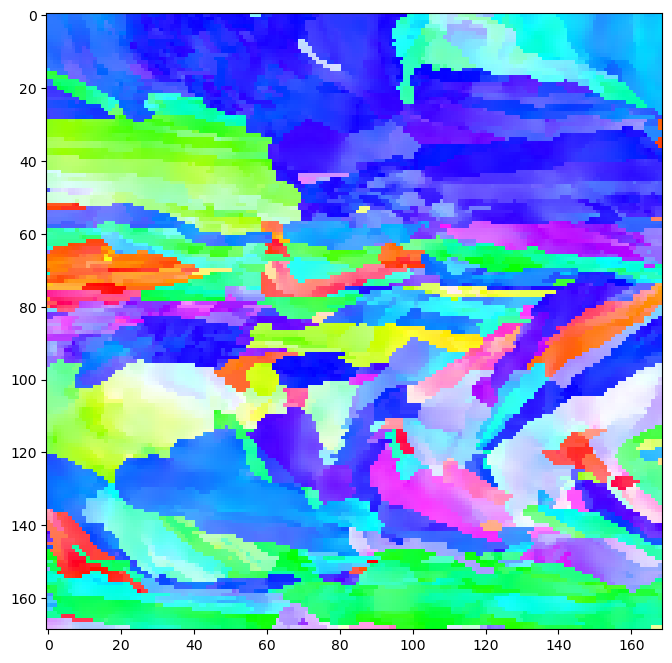

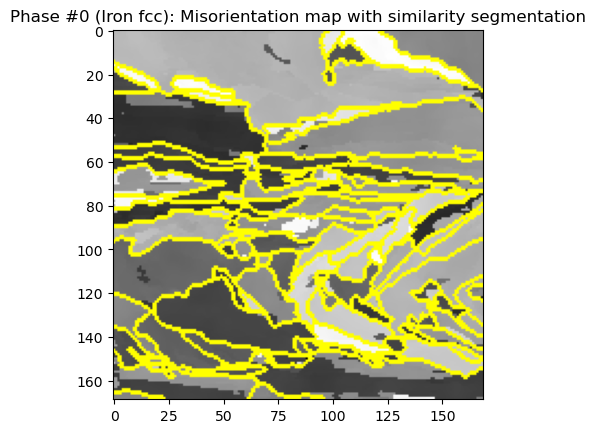

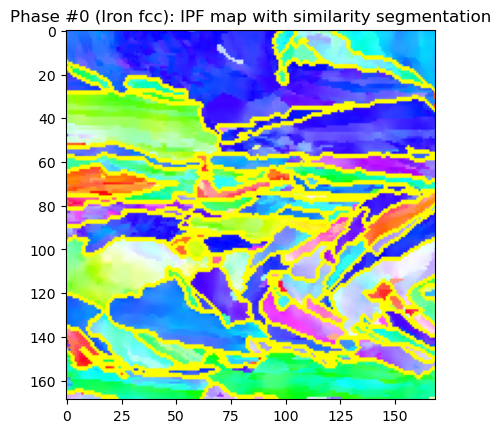

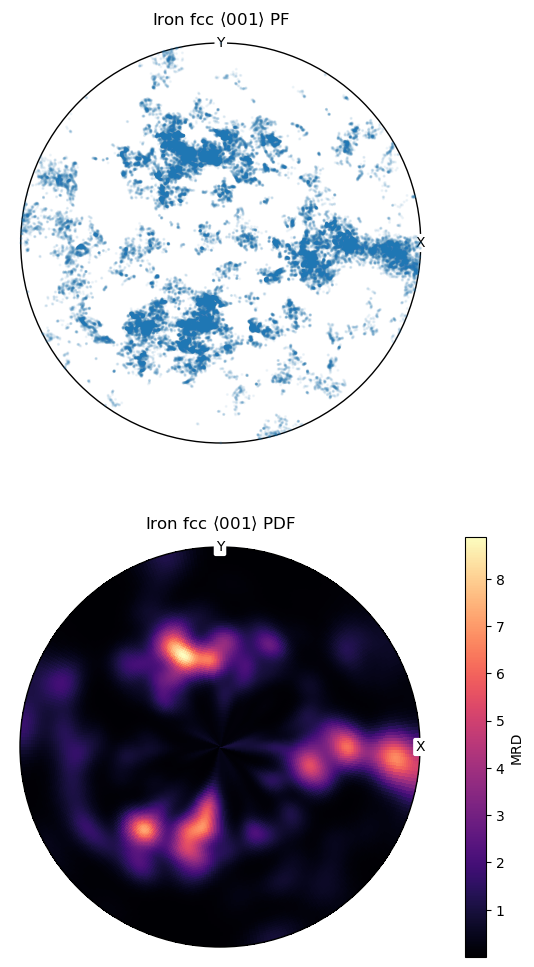

EBSD file loaded successfully!
  -> Current working directory: /home/yousef/damaskWorkflows/ebsd2kanapy2damask/microstructure_workflows/cases/Tensile and Rolling
  -> EBSD file: ebsd_316L_500x500.ang



EBSD map loading is completed ........................................................
########################################################################################



########################################################################################
Extracting microstructure statistics .................................................






Microstructure statistics extracting is completed .................................
#####################################################################################



########################################################################################
Generating RVE .......................................................................



Creating an RVE based on user defined statistics
    Analyzed statistical data for p

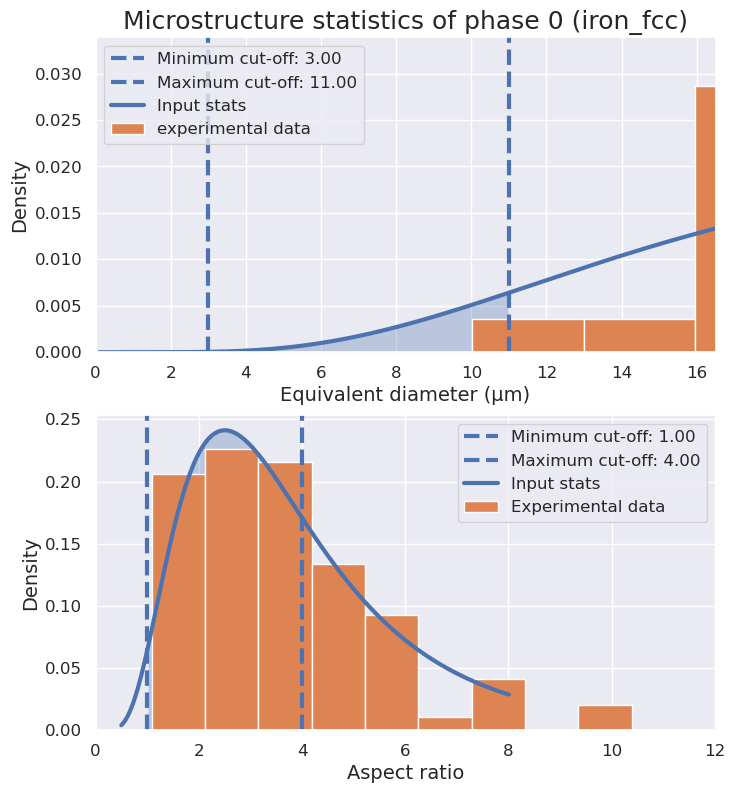

Starting particle simulation
    Creating particles from distribution statistics
    Total volume of generated ellipsoids: 3901.9991324067914
    Particle packing by growth simulation
Volume of simulation box: 3375
Volume of unscaled particles: 3901.9991324067923
Initial volume of scaled ellipsoids: 3.901999132406793, targeted final volume: 2536.2994360644147
Volume increment per time step: 3.901999132406792


100%|██████████████████████████████████████████████████████████████████████████████| 1441/1441 [00:07<00:00, 184.96it/s]


Actual final volume of ellipsoids: 2532.8825037163856
Completed particle packing
45 overlapping particles detected after packing
Kinetic energy of particles after packing: 11524.749156484786






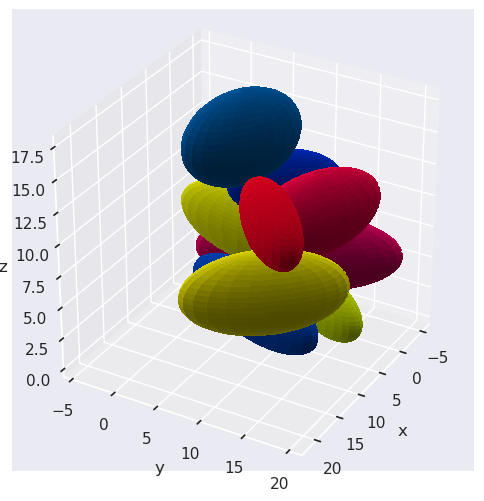

    Generating voxels inside RVE

Starting RVE voxelization
    Assigning voxels to grains


100%|██████████████████████████████████████████████████████████████████████████| 3375/3375 [00:00<00:00, 3203389.00it/s]


Completed RVE voxelization






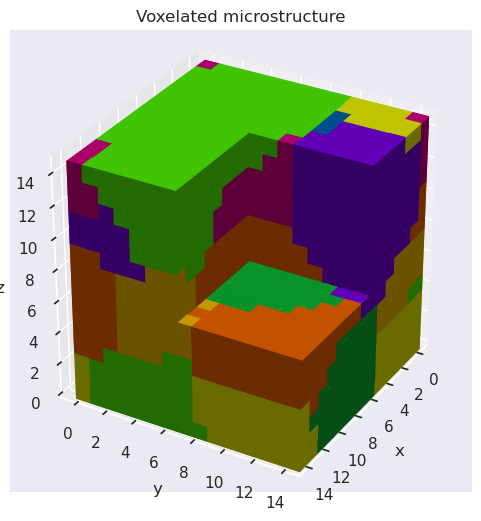


Generated Delaunay tesselation of grain vertices.
Assigning 375 tetrahedra to grains ...


375it [00:00, 389.72it/s]

Finished generating polyhedral hulls for grains.
Total volume of RVE: 3375 um^3
Total volume of polyhedral grains: 3374.9999999999995 um^3
Mean relative error of polyhedral vs. voxel volume of individual grains: 0.1
for mean volume of grains: 375.0 um^3.


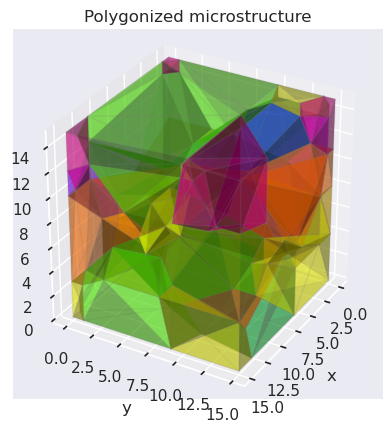

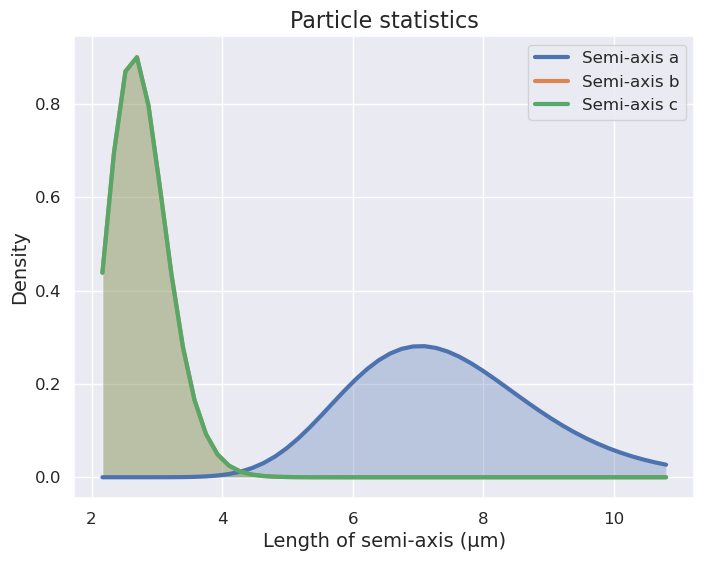

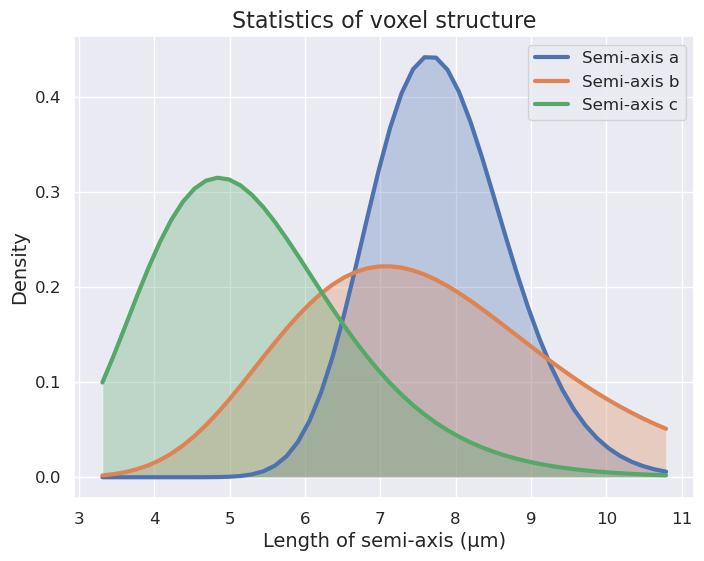

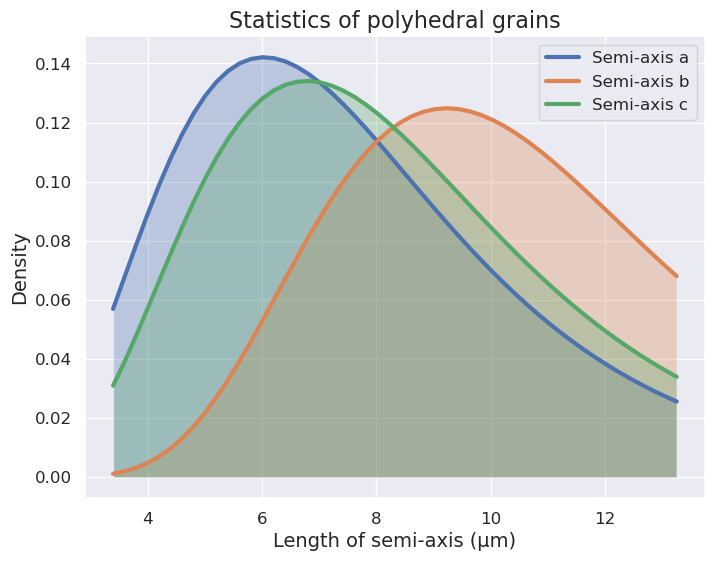


Statistical microstructure parameters of RVE
--------------------------------------------
Type	| a (µm) 	| b (µm) 	| c (µm) 	| std.dev	| rot.axis	| asp.ratio	| std.dev	| equ.dia. (µm)	| std.dev
Partcls	|  7.315	|  2.714	|  2.714	|  0.1755	|     0   	|  2.695	|  0.1443	|     7.797 	|  0.1660
Voxels	|  7.762	|  7.516	|  5.175	|  0.2051	|     2   	|  0.677	|  0.0633	|     12.897 	|  0.1839
Grains	|  7.229	|  10.281	|  7.988	|  0.3857	|     1   	|  1.351	|  0.2176	|     16.203 	|  0.1847


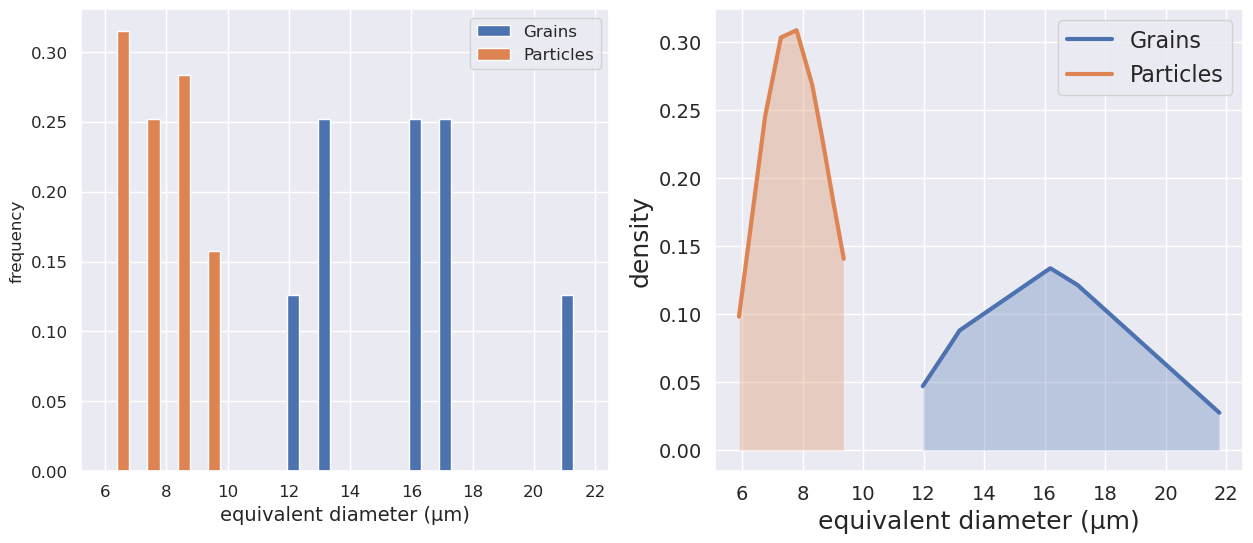

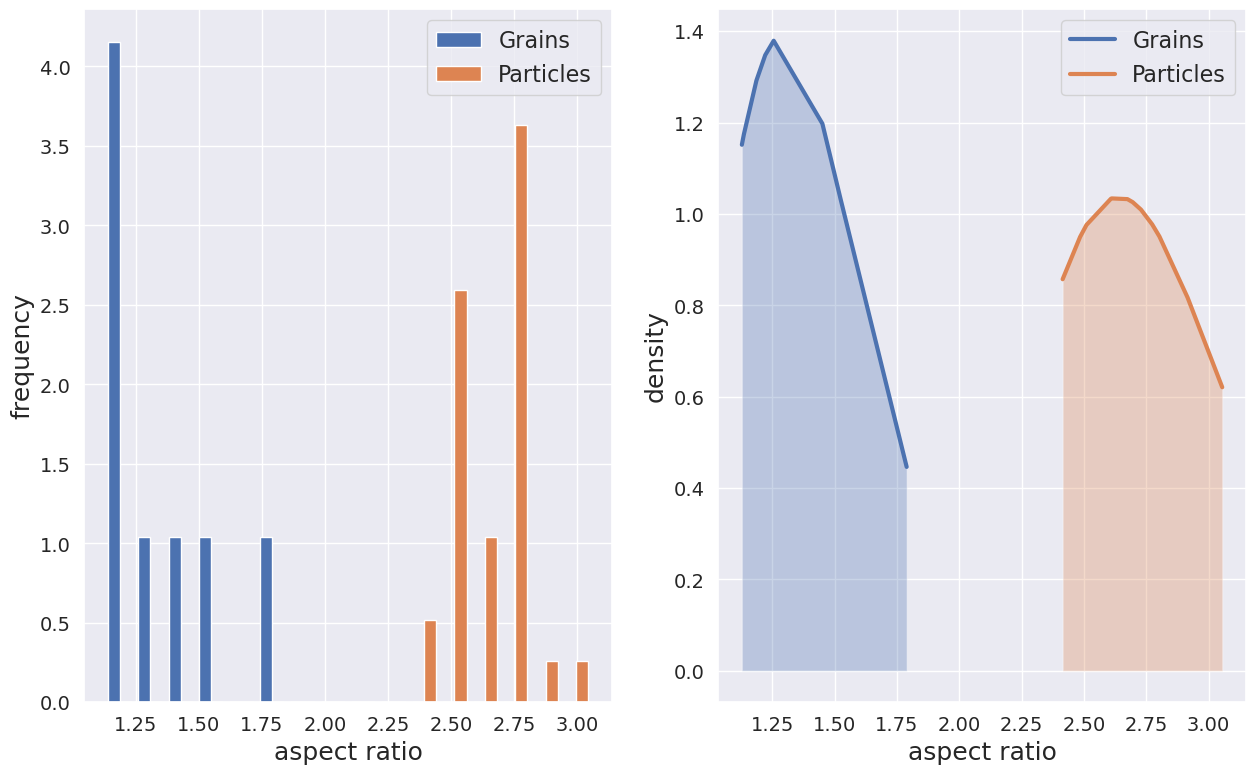

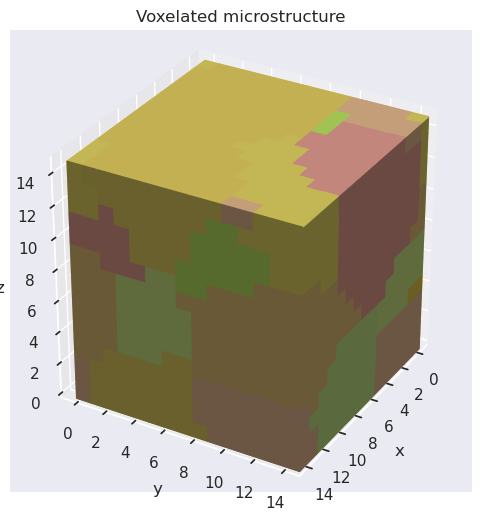




RVE generating is completed ........................................................
######################################################################################



########################################################################################
Exporting MiMeDO .......................................................................



Saved to: /home/yousef/damaskWorkflows/ebsd2kanapy2damask/microstructure_workflows/cases/Tensile and Rolling/Keys/1e77271a_f28fd_S_c894c942/results/1e77271a.json
Folder key: 1e77271a_f28fd_S_c894c942



MiMeDO is exported .................................................................
######################################################################################



########################################################################################
Building grid/material/load from JSON ................................................



cells:  15 × 15 × 15
size:   1.4999999999999999e-05 × 1.4999999999999999e-05 × 1.499

/home/yousef/damaskWorkflows/ebsd2kanapy2damask/microstructure_workflows/functions/nodes.py:2115: UserWarning: export_microstructure='voxels_with_grains' copies the initial grain dictionary into deformed snapshots. These grain-level fields are not updated by segmentation or grain-ID tracking. Use this mode only as an intermediate export. For physically meaningful grain-level evolution, post-process the result with grain segmentation and grain-ID tracking.
  updated_json = result.export_mimedo(


[OK] Homogenized mechanical response exported.
[OK] Top-level time was not exported.

[INFO] Streaming updated MiMeDat JSON to temporary file: /home/yousef/damaskWorkflows/ebsd2kanapy2damask/microstructure_workflows/cases/Tensile and Rolling/Keys/1e77271a_f28fd_S_c894c942/results/1e77271a.json.tmp

[INFO] Exporting microstructure snapshots...
[INFO] Microstructure mode: voxels_with_grains
[INFO] Microstructure increments selected: 11
[INFO] Microstructure stride: 10
[INFO] Microstructure quantities: ['O', 'F', 'sigma', 'epsilon_V^0.0(F)']
[INFO]  increment_1 | t=1 | grid_size=[1.39650491e-05 1.40426206e-05 1.40046826e-05] | grid_spacing=[9.97107507e-07 1.00234183e-06 1.00002811e-06]
[INFO] Wrote microstructure snapshot increment_1 (1/11)
[INFO] increment_11 | t=11 | grid_size=[1.36466667e-05 1.45862850e-05 1.40758557e-05] | grid_spacing=[9.68665962e-07 1.02945723e-06 9.99787720e-07]
[INFO] Wrote microstructure snapshot increment_11 (2/11)
[INFO] Wrote microstructure snapshot increment_

Segmenting snapshots:   0%|          | 0/12 [00:00<?, ?snapshot/s]


snap     status     mode         grid    BFS  final  merges   old     ARI
   0 undeformed ARI-only     15x15x15     10      9       1     9     nan
   1   deformed    write     15x15x15     10      9       1     9     nan
   2   deformed    write     15x15x15     10      9       1     9     nan
   3   deformed    write     15x15x15     12      9       3     9     nan
   4   deformed    write     15x15x15     30      9      21     9     nan
   5   deformed    write     15x15x15     82      9      73     9     nan
   6   deformed    write     15x15x15    187      9     178     9     nan
   7   deformed    write     15x15x15    279     10     269     9     nan
   8   deformed    write     15x15x15    383     11     372     9     nan
   9   deformed    write     15x15x15    481     12     469     9     nan
  10   deformed    write     15x15x15    553     13     540     9     nan
  11   deformed    write     15x15x15    642     12     630     9     nan

wrote /home/yousef/damaskWorkflows/e

Tracking grain IDs:   0%|          | 0/11 [00:00<?, ?it/s]



[OK] Update JSON, grain ids are updated




[OK] IPF colors are added


###################################################################################################
Start regridding and mapping ....................................................................




GRID UPDATE SUMMARY

Snapshots used:
  • Snapshot 0      : index = 0, time = None
  • Target snapshot : index = 11, time = None

Length unit: m

Grid comparison (old → new):
------------------------------------------------------------------------
Quantity           Old                      New                     
------------------------------------------------------------------------
Grid size [m]      [1.5e-05, 1.5e-05, 1.5e-05] → [1.05e-05, 2.17e-05, 1.47e-05]
Grid spacing [m]   [1e-06, 1e-06, 1e-06] → [7e-07, 7e-07, 7e-07]
Voxel counts       [15, 15, 15] → [15, 31, 21]
------------------------------------------------------------------------

Average deformation gradient F_avg:
[[ 0.7     0.     -0.    ]
 [-0. 

In [10]:
wf.run();

## 9. Results

Two things to check:

1. **A&ndash;D share one microstructure** &mdash; their keys differ only in the
   first hash, since `mechanical_BC` is a hashed identifier field while the
   orientation and microstructure ids are not.
2. **E&ndash;G share a different one** &mdash; D's rolled microstructure. Their
   keys end in the `microstructure_state_id` that D stamped on its recovered
   snapshot, not the initial one.

In [11]:
print("initial RVE")
for name, node in [("A", wf.branch_A), ("B", wf.branch_B),
                   ("C", wf.branch_C), ("D", wf.branch_D)]:
    print(f"  {name}   {node.outputs.key.value}")

print()
print("D's recovered microstructure:", wf.branch_D.outputs.recovered_state_id.value)
for name, node in [("E", wf.branch_E), ("F", wf.branch_F), ("G", wf.branch_G)]:
    print(f"  {name}   {node.outputs.key.value}")

initial RVE
  A   f8cd8adc_f28fd_S_c894c942
  B   db6a698a_f28fd_S_c894c942
  C   3ab61a93_f28fd_S_c894c942
  D   1e77271a_f28fd_S_c894c942

D's recovered microstructure: S_bfa395ad
  E   8e9fb909_ef14f_S_bfa395ad
  F   df0b89c2_ef14f_S_bfa395ad
  G   dc1be515_ef14f_S_bfa395ad


## 10. Investigate results

Explore the finished MiMeDOs side by side &mdash; microstructure
snapshots, texture, mechanical response. Requires `ipywidgets`.

In [13]:
from functions.mimedo_viewer import mimedat_viewer

# Rolling tension along the same axis, side by side.
mimedat_viewer(
    "Keys/1e77271a_f28fd_S_c894c942/results/1e77271a.json",
)

Output()